## 5. Modeling

### Objective

Build and compare an early-risk baseline and an ensemble model using the
feature table created in Notebook 03.

The validation design keeps all records from the same student in the same
fold, because one student can appear in multiple course records.

**Workflow:** target & groups → leakage check → preprocessing → grouped CV →
model comparison → OOF evaluation → threshold analysis → final model.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, accuracy_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
import joblib

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = PROCESSED_DIR
FEATURE_FILE = PROCESSED_DIR / "early_risk_features.csv"

print("BASE_DIR:", BASE_DIR)
print("Feature file:", FEATURE_FILE)


BASE_DIR: d:\Early Risk Detection for Student Success - OULAD
Feature file: d:\Early Risk Detection for Student Success - OULAD\data\processed\early_risk_features.csv


## 2. Load the Feature Table

We use the leakage-controlled feature table from Notebook 03 rather than
joining the raw tables again.


In [3]:
df = pd.read_csv(FEATURE_FILE)
print("Shape:", df.shape)
print("Unique student-course records:",
      df[["id_student", "code_module", "code_presentation"]].drop_duplicates().shape[0])
df.head()


Shape: (32593, 26)
Unique student-course records: 32593


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,early_median_score,early_max_score,early_score_std,early_missing_scores,early_assessment_weight,total_clicks,active_days,active_sites,avg_clicks_per_active_day,no_early_vle_activity
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,78.0,78.0,NaN,0.0,10.0,400.0,8.0,24.0,50.000000,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,70.0,70.0,NaN,0.0,10.0,609.0,19.0,34.0,32.052632,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,NaN,NaN,NaN,NaN,260.0,12.0,22.0,21.666667,0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,72.0,72.0,NaN,0.0,10.0,469.0,22.0,31.0,21.318182,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.0,69.0,NaN,0.0,10.0,559.0,24.0,34.0,23.291667,0


## 3. Define Target, Group, and Model Features

- **Target:** `is_at_risk` = Fail or Withdrawn.
- **Group:** `id_student`.
- `id_student` is used only for grouping, not as a predictive feature.
- Final outcome fields are excluded from the inputs.


In [4]:
TARGET = "is_at_risk"
GROUP = "id_student"

assert TARGET in df.columns
assert GROUP in df.columns

features = df.copy()

# A student-course record is the modeling unit.
assert len(features) == features[
    [GROUP, "code_module", "code_presentation"]
].drop_duplicates().shape[0]

y = features[TARGET].astype(int)
groups = features[GROUP]

X = features.drop(columns=[TARGET, GROUP])

# Explicit outcome/post-outcome leakage exclusions.
leakage_cols = [
    "final_result",
    "date_unregistration",
    "date_unregistration_missing",
]

present_leakage = [c for c in leakage_cols if c in X.columns]
assert not present_leakage, f"Leakage columns found: {present_leakage}"

print("Target rate:", round(y.mean(), 4))
print("Model input features:", X.shape[1])
print("Students:", groups.nunique())


Target rate: 0.528
Model input features: 24
Students: 28785


## 4. Leakage Check

The target and student identifier must not be model inputs. The early
assessment and VLE features were already restricted to the day-28 cutoff in
Notebook 03.

The validation check below also confirms that a student never appears in both
training and validation within a fold.


In [5]:
assert TARGET not in X.columns
assert GROUP not in X.columns

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_rows = []
for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y, groups), start=1):
    train_students = set(groups.iloc[train_idx])
    valid_students = set(groups.iloc[valid_idx])
    overlap = train_students & valid_students

    assert len(overlap) == 0
    fold_rows.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "valid_risk_rate": y.iloc[valid_idx].mean(),
        "student_overlap": len(overlap),
    })

fold_check = pd.DataFrame(fold_rows)
fold_check


,fold,train_rows,valid_rows,valid_risk_rate,student_overlap
0,1,26104,6489,0.520265,0
1,2,26057,6536,0.529988,0
2,3,26100,6493,0.531957,0
3,4,26014,6579,0.529260,0
4,5,26097,6496,0.528325,0


## 5. Preprocessing

Numeric variables use median imputation and scaling. Categorical variables
use the most frequent category and one-hot encoding.

All preprocessing is inside the pipeline so it is fitted separately inside
each training fold.


In [6]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))


Numeric features: 16
Categorical features: 8


## 6. Define the Models

### Baseline - Logistic Regression
A simple, interpretable linear model.

### Ensemble - Random Forest
An ensemble of decision trees that can capture nonlinear relationships and
feature interactions.


In [7]:
baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

ensemble = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Logistic Regression": baseline,
    "Random Forest": ensemble,
}


## 7. Five-Fold Stratified Group Cross-Validation

We compare the models on the same five grouped folds.

The main model-selection metric is **Average Precision (AP)** because the
project is an early-risk problem and precision-recall behavior is more useful
than accuracy alone.


In [8]:
def evaluate_cv(model, X, y, groups, cv):
    fold_metrics = []
    oof_prob = np.full(len(y), np.nan)

    for fold, (train_idx, valid_idx) in enumerate(
        cv.split(X, y, groups), start=1
    ):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        prob = model.predict_proba(X.iloc[valid_idx])[:, 1]
        pred = (prob >= 0.50).astype(int)

        oof_prob[valid_idx] = prob

        fold_metrics.append({
            "fold": fold,
            "AP": average_precision_score(y.iloc[valid_idx], prob),
            "ROC AUC": roc_auc_score(y.iloc[valid_idx], prob),
            "Precision": precision_score(y.iloc[valid_idx], pred, zero_division=0),
            "Recall": recall_score(y.iloc[valid_idx], pred, zero_division=0),
            "F1": f1_score(y.iloc[valid_idx], pred, zero_division=0),
            "Accuracy": accuracy_score(y.iloc[valid_idx], pred),
        })

    return pd.DataFrame(fold_metrics), oof_prob

results = {}
oof = {}

for name, model in models.items():
    fold_metrics, oof_prob = evaluate_cv(model, X, y, groups, cv)
    results[name] = fold_metrics
    oof[name] = oof_prob

    print("\n", name)
    print(fold_metrics.round(4))
    print("Mean AP:", round(fold_metrics["AP"].mean(), 4))



 Logistic Regression
   fold      AP  ROC AUC  Precision  Recall      F1  Accuracy
0     1  0.8418   0.8153     0.7509  0.7225  0.7364    0.7309
1     2  0.8652   0.8309     0.7879  0.7269  0.7562    0.7515
2     3  0.8611   0.8221     0.7673  0.7226  0.7443    0.7359
3     4  0.8476   0.8139     0.7612  0.7298  0.7452    0.7358
4     5  0.8401   0.8075     0.7496  0.7197  0.7344    0.7249
Mean AP: 0.8512

 Random Forest
   fold      AP  ROC AUC  Precision  Recall      F1  Accuracy
0     1  0.8642   0.8321     0.7855  0.7094  0.7455    0.7480
1     2  0.8799   0.8449     0.8166  0.7159  0.7630    0.7642
2     3  0.8744   0.8354     0.8025  0.7105  0.7537    0.7530
3     4  0.8785   0.8427     0.8121  0.7260  0.7666    0.7661
4     5  0.8611   0.8239     0.7856  0.6920  0.7359    0.7375
Mean AP: 0.8716


## 8. Model Comparison

The table reports the mean and standard deviation across the five grouped
validation folds.


In [9]:
summary_rows = []

for name, fold_metrics in results.items():
    summary_rows.append({
        "Model": name,
        "AP": fold_metrics["AP"].mean(),
        "AP std": fold_metrics["AP"].std(),
        "ROC AUC": fold_metrics["ROC AUC"].mean(),
        "Precision": fold_metrics["Precision"].mean(),
        "Recall": fold_metrics["Recall"].mean(),
        "F1": fold_metrics["F1"].mean(),
        "Accuracy": fold_metrics["Accuracy"].mean(),
    })

model_comparison = pd.DataFrame(summary_rows).sort_values(
    "AP", ascending=False
).reset_index(drop=True)

model_comparison.round(4)


,Model,AP,AP std,ROC AUC,Precision,Recall,F1,Accuracy
0,Random Forest,0.8716,0.0085,0.8358,0.8005,0.7108,0.7529,0.7538
1,Logistic Regression,0.8512,0.0114,0.8179,0.7634,0.7243,0.7433,0.7358


## 9. Out-of-Fold (OOF) Performance

OOF probabilities give one prediction for every record while keeping each
prediction out of the model's training fold. This provides a clean basis for
the overall curves and threshold analysis.


In [10]:
best_model_name = model_comparison.loc[0, "Model"]
best_oof_prob = oof[best_model_name]

oof_predictions = pd.DataFrame({
    "id_student": groups.values,
    "code_module": df["code_module"].values,
    "code_presentation": df["code_presentation"].values,
    "actual": y.values,
    "predicted_probability": best_oof_prob,
})
oof_predictions["predicted_class"] = (
    oof_predictions["predicted_probability"] >= 0.50
).astype(int)

print("Selected model:", best_model_name)
print("OOF AP:", round(average_precision_score(y, best_oof_prob), 4))
print("OOF ROC AUC:", round(roc_auc_score(y, best_oof_prob), 4))


Selected model: Random Forest
OOF AP: 0.8716
OOF ROC AUC: 0.8358


## 10. Precision - Recall Curve

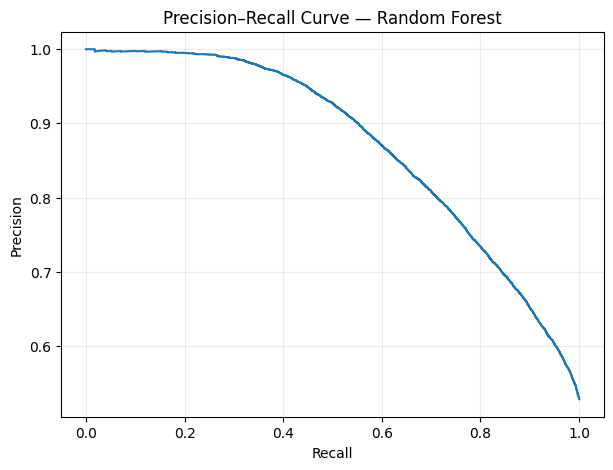

In [11]:
precision, recall, pr_thresholds = precision_recall_curve(y, best_oof_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve — {best_model_name}")
plt.grid(alpha=0.25)
plt.show()


## 11. ROC Curve

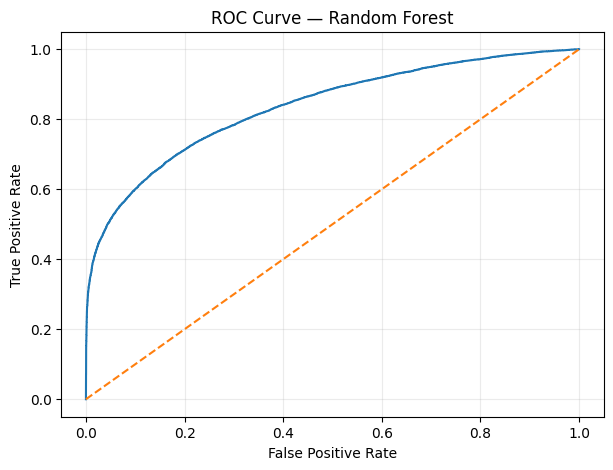

In [12]:
fpr, tpr, roc_thresholds = roc_curve(y, best_oof_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {best_model_name}")
plt.grid(alpha=0.25)
plt.show()


## 12. Confusion Matrix at Threshold 0.50

In [13]:
cm = confusion_matrix(y, oof_predictions["predicted_class"])
tn, fp, fn, tp = cm.ravel()

print("Confusion matrix:")
print(cm)
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Confusion matrix:
[[12337  3048]
 [ 4976 12232]]
TN=12337, FP=3048, FN=4976, TP=12232


## 13. Threshold Sensitivity

The probability threshold changes the trade-off between how many at-risk
students are caught and how many alerts are sent to advisors.


In [14]:
threshold_rows = []

for threshold in np.arange(0.30, 0.71, 0.10):
    pred = (best_oof_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "flagged": int(pred.sum()),
        "flagged_pct": pred.mean(),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "f1": f1_score(y, pred, zero_division=0),
    })

threshold_table = pd.DataFrame(threshold_rows)
threshold_table.round(4)


,threshold,flagged,flagged_pct,precision,recall,f1
0,0.3,24388,0.7483,0.6419,0.9098,0.7527
1,0.4,19473,0.5975,0.7211,0.8160,0.7656
2,0.5,15280,0.4688,0.8005,0.7108,0.7530
3,0.6,12018,0.3687,0.8663,0.6050,0.7124
4,0.7,9479,0.2908,0.9224,0.5081,0.6552


## 14. Fit the Final Selected Model

After model selection, fit the chosen pipeline on the complete feature table.
This model is the artifact that can be reused by the interpretability
notebook.


In [19]:
final_model = models[best_model_name]
final_model.fit(X, y)

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "best_early_risk_model.joblib"
comparison_path = OUTPUT_DIR / "model_comparison.csv"
oof_path = OUTPUT_DIR / "oof_predictions.csv"

joblib.dump(final_model, model_path)
model_comparison.to_csv(comparison_path, index=False)
oof_predictions.to_csv(oof_path, index=False)

print("Saved:")
print(model_path)
print(comparison_path)
print(oof_path)


Saved:
d:\Early Risk Detection for Student Success - OULAD\models\best_early_risk_model.joblib
d:\Early Risk Detection for Student Success - OULAD\data\processed\model_comparison.csv
d:\Early Risk Detection for Student Success - OULAD\data\processed\oof_predictions.csv


## 15. Final Modeling Insight

The final conclusion below is generated from the actual cross-validation
results above rather than from a generic expectation.

- The selected model is the model with the highest mean AP across the five
  student-grouped folds.
- The threshold table should be used to choose an operating point based on
  advisor capacity and the relative cost of missed-risk versus extra alerts.
- Grouped validation is essential because students can have multiple
  student-course records.


In [20]:
best_row = model_comparison.iloc[0]

print(
    f"Selected model: {best_row['Model']} | "
    f"AP={best_row['AP']:.4f} | "
    f"ROC AUC={best_row['ROC AUC']:.4f} | "
    f"F1={best_row['F1']:.4f} | "
    f"Accuracy={best_row['Accuracy']:.4f}"
)
print(
    f"At threshold 0.50: TP={tp}, FN={fn}, FP={fp}, TN={tn}"
)


Selected model: Random Forest | AP=0.8716 | ROC AUC=0.8358 | F1=0.7529 | Accuracy=0.7538
At threshold 0.50: TP=12232, FN=4976, FP=3048, TN=12337
